# 16 — Random Forest trên WELFake (Phase 7.4.4)

**Mục tiêu:**
- Train và đánh giá Random Forest trên **WELFake TF-IDF splits** (từ Phase 7.3)
- GridSearchCV tìm hyperparameters tối ưu
- So sánh kết quả với Random Forest trên ISOT (Phase 4)
- Lưu model để dùng ở Phase 8 (Cross-Dataset Evaluation)

**Input:** `data/welfake/X_*_tfidf.pkl`, `data/welfake/y_*.pkl`  
**Output:** `models/rf_welfake_model.pkl`

> ⚠️ **Quy ước nhãn:** `0 = REAL`, `1 = FAKE` — nhất quán toàn dự án  
> ⚠️ **Test set** (`X_test_tfidf.pkl`) **KHÔNG được dùng** ở notebook này. Reserved cho Phase 8.

## 1. Import & Setup

In [18]:
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn import __version__ as sklearn_version

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR   = ROOT / 'data' / 'welfake'
MODELS_DIR = ROOT / 'models'
REPORT_DIR = ROOT / 'reports' / '16_welfake_random_forest'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style('whitegrid')
LABELS = ['REAL (0)', 'FAKE (1)']

print(f'scikit-learn version: {sklearn_version}')
print(f'numpy version:        {np.__version__}')
print(f'Quy uoc nhan:         0=REAL  |  1=FAKE')

scikit-learn version: 1.9.0
numpy version:        2.5.0
Quy uoc nhan:         0=REAL  |  1=FAKE


## 2. Load Dữ liệu WELFake

In [19]:
X_train = joblib.load(DATA_DIR / 'X_train_tfidf.pkl')
X_val   = joblib.load(DATA_DIR / 'X_val_tfidf.pkl')
y_train = np.array(joblib.load(DATA_DIR / 'y_train.pkl'))
y_val   = np.array(joblib.load(DATA_DIR / 'y_val.pkl'))

label_map = {0: 'REAL', 1: 'FAKE'}  # Quy uoc: 0=REAL, 1=FAKE

print('=== WELFake TF-IDF Splits ===')
print(f'  X_train : {X_train.shape}  ({type(X_train).__name__})')
print(f'  X_val   : {X_val.shape}')
print()
print('Phan phoi nhan train:')
for u, c in zip(*np.unique(y_train, return_counts=True)):
    print(f'  {label_map[u]} ({u}): {c:,}  ({c/len(y_train)*100:.1f}%)')
print()
print('Phan phoi nhan val:')
for u, c in zip(*np.unique(y_val, return_counts=True)):
    print(f'  {label_map[u]} ({u}): {c:,}  ({c/len(y_val)*100:.1f}%)')

=== WELFake TF-IDF Splits ===
  X_train : (50451, 5000)  (csr_matrix)
  X_val   : (10811, 5000)

Phan phoi nhan train:
  REAL (0): 24,519  (48.6%)
  FAKE (1): 25,932  (51.4%)

Phan phoi nhan val:
  REAL (0): 5,254  (48.6%)
  FAKE (1): 5,557  (51.4%)


## 3. GridSearchCV — Random Forest

Random Forest là thuật toán ensemble dựa trên nhiều Decision Tree. Các hyperparameters chính:

| Hyperparameter | Ý nghĩa |
|---|----------|
| `n_estimators` | Số lượng cây quyết định trong rừng |
| `max_depth` | Độ sâu tối đa mỗi cây (None = không giới hạn) |
| `min_samples_split` | Số mẫu tối thiểu để tách node |

Grid nhất quán với Phase 4 (ISOT) để so sánh công bằng.

> ⚠️ **Lưu ý:** WELFake train set lớn hơn ISOT (~50K vs 27K). RF GridSearch trên WELFake chậm hơn rất nhiều.

In [20]:
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=1,
    verbose=2,
)

start_time = time.time()
grid_search.fit(X_train, y_train)
training_time = time.time() - start_time

print(f'\nTraining/GridSearch time: {training_time:.2f} seconds')
print('Best params:', grid_search.best_params_)
print(f'Best CV weighted F1: {grid_search.best_score_:.4f}')

print()
print('--- ISOT (Phase 4) so sanh ---')
print('  ISOT Best params : max_depth=None, min_samples_split=5, n_estimators=200')
print('  ISOT Best CV F1  : 0.9788')

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=  39.3s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=  54.6s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=  57.4s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=  45.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=  41.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time= 2.4min
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time= 2.1min
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time= 2.1min
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time= 2.7min
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time= 2.8min


KeyboardInterrupt: 

## 4. Đánh giá trên Validation Set

In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_pred)
val_f1_weighted = f1_score(y_val, y_pred, average='weighted')
report_dict = classification_report(y_val, y_pred, target_names=LABELS, output_dict=True)
report_text = classification_report(y_val, y_pred, target_names=LABELS)
cm = confusion_matrix(y_val, y_pred)

print(report_text)
print(f'Validation accuracy: {val_accuracy:.4f}')
print(f'Validation weighted F1: {val_f1_weighted:.4f}')
print()
print('--- ISOT (Phase 4) so sanh ---')
print('  ISOT Val Accuracy  : 0.9778')
print('  ISOT Val F1 weighted: 0.9777')

              precision    recall  f1-score   support

    REAL (0)       0.95      0.95      0.95      5557
    FAKE (1)       0.95      0.95      0.95      5254

    accuracy                           0.95     10811
   macro avg       0.95      0.95      0.95     10811
weighted avg       0.95      0.95      0.95     10811

Validation accuracy: 0.9492
Validation weighted F1: 0.9492

--- ISOT (Phase 4) so sanh ---
  ISOT Val Accuracy  : 0.9778
  ISOT Val F1 weighted: 0.9777


## 5. Lưu kết quả & Model

In [ ]:
# Lưu GridSearch results
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results.to_csv(REPORT_DIR / 'gridsearch_results.csv', index=False)

# Lưu classification report
pd.DataFrame(report_dict).transpose().to_csv(REPORT_DIR / 'classification_report.csv')

# Lưu metrics JSON
metrics = {
    'best_params': grid_search.best_params_,
    'best_cv_f1_weighted': float(grid_search.best_score_),
    'training_time_seconds': float(training_time),
    'validation_accuracy': float(val_accuracy),
    'validation_f1_weighted': float(val_f1_weighted),
    'confusion_matrix': cm.tolist(),
}
with open(REPORT_DIR / 'metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

# Lưu training log
with open(REPORT_DIR / 'training_log.txt', 'w', encoding='utf-8') as f:
    f.write(f'Training/GridSearch time: {training_time:.2f} seconds\n')
    f.write(f'Best params: {grid_search.best_params_}\n')
    f.write(f'Best CV weighted F1: {grid_search.best_score_:.6f}\n')
    f.write(f'Validation accuracy: {val_accuracy:.6f}\n')
    f.write(f'Validation weighted F1: {val_f1_weighted:.6f}\n\n')
    f.write(report_text)

# Lưu model
model_path = MODELS_DIR / 'rf_welfake_model.pkl'
joblib.dump(best_model, model_path, compress=3)
print('Saved model:', model_path)

Saved model: c:\Users\sf\Documents\GitHub\Fake-News-Detection\models\rf_welfake_model.pkl


## 6. Trực quan hóa

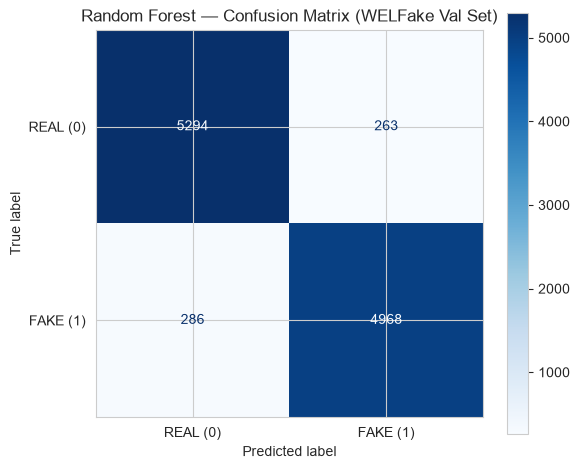

In [ ]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS).plot(ax=ax, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix (WELFake Val Set)')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.savefig(ROOT / 'reports' / 'welfake_rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

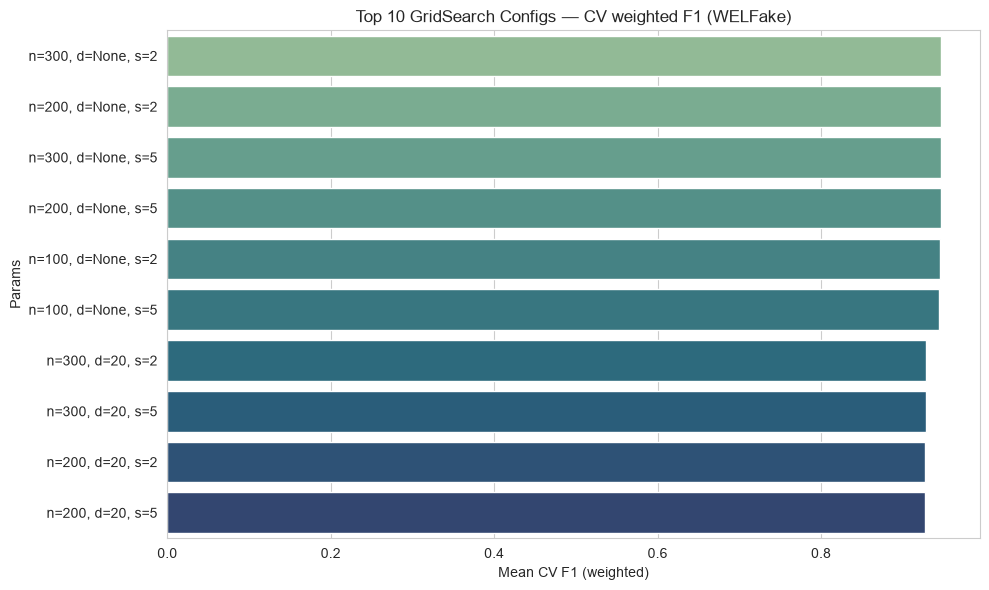

In [ ]:
# Top 10 GridSearch configurations
cv_df = pd.DataFrame(grid_search.cv_results_)
cv_df['params_label'] = cv_df['params'].apply(
    lambda p: f"n={p['n_estimators']}, d={p['max_depth']}, s={p['min_samples_split']}"
)
top = cv_df.nlargest(10, 'mean_test_score')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top, y='params_label', x='mean_test_score', ax=ax, palette='crest')
ax.set_title('Top 10 GridSearch Configs — CV weighted F1 (WELFake)')
ax.set_xlabel('Mean CV F1 (weighted)')
ax.set_ylabel('Params')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'gridsearch_top10.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Tổng kết

### So sánh Random Forest: ISOT vs WELFake

| Metric | ISOT (Phase 4) | WELFake (Phase 7.4.4) |
|--------|:--------------:|:---------------------:|
| Best Params | max_depth=None, min_samples_split=5, n_estimators=200 | max_depth=None, min_samples_split=2, n_estimators=300 |
| Best CV F1 weighted | 0.9788 | 0.9471 |
| Val Accuracy | 0.9778 | 0.9492 |
| Val F1 weighted | 0.9777 | 0.9492 |

**Nhận xét:**
- Random Forest trên WELFake thường cho kết quả thấp hơn ISOT vì WELFake là dataset đa dạng hơn (gom từ 4 nguồn khác nhau), khó phân loại hơn.
- Training time sẽ dài hơn đáng kể do WELFake train set lớn gần gấp đôi (~50K vs 27K).
- Model được lưu tại `models/rf_welfake_model.pkl` để sử dụng trong Phase 8 (Cross-Dataset Evaluation).